<a href="https://colab.research.google.com/github/yadavrishikesh/Deep-Learning-Slides-Code/blob/main/code/CNN/CNN_for_time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries (run once in notebook)
!pip install yfinance tensorflow scikit-learn matplotlib

# Numerical computations
import numpy as np

# Data handling (tables, time series)
import pandas as pd

# Plotting library
import matplotlib.pyplot as plt

# Download financial time series data
import yfinance as yf

# TensorFlow deep learning library
import tensorflow as tf

# Import layers and model API from TensorFlow
from tensorflow.keras import layers, models

# Scaling data between 0 and 1
from sklearn.preprocessing import MinMaxScaler

## Load Real Time Series Data

/tmp/ipykernel_18215/2197541043.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2018-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price           Close
Ticker           AAPL
Date                 
2018-01-02  40.304184
2018-01-03  40.297153
2018-01-04  40.484337
2018-01-05  40.945271
2018-01-08  40.793179


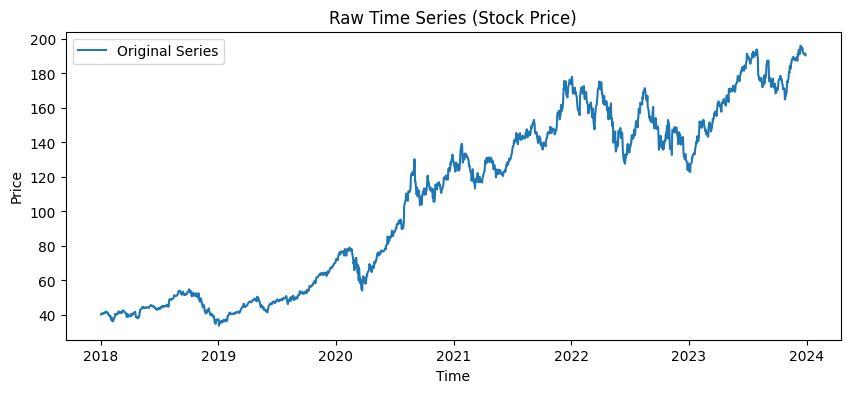

In [3]:
# Download Apple stock data from Yahoo Finance
df = yf.download("AAPL", start="2018-01-01", end="2024-01-01")

# Keep only closing price (univariate time series)
df = df[['Close']]

# Show first few rows
print(df.head())
# Plot entire time series
plt.figure(figsize=(10,4))
plt.plot(df['Close'], label='Original Series')
plt.title("Raw Time Series (Stock Price)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

## Normalize Data

In [4]:
# Initialize scaler (maps values to [0,1])
scaler = MinMaxScaler()

# Fit and transform data
data = scaler.fit_transform(df.values)

# Print first few normalized values
print("Scaled Data Sample:\n", data[:5])

Scaled Data Sample:
 [[0.04027046]
 [0.04022715]
 [0.04138043]
 [0.04422035]
 [0.04328328]]


## Convert Time Series → Supervised Learning

CNN cannot directly read time series → we create sliding windows

In [5]:
# Function to create sequences
def create_sequences(data, window=20):
    X = []  # input sequences
    y = []  # target values

    # Loop over time series
    for i in range(len(data) - window):
        X.append(data[i:i+window])      # past window values
        y.append(data[i+window])        # next value

    return np.array(X), np.array(y)

# Define window size
window_size = 20

# Create dataset
X, y = create_sequences(data, window_size)

# Print shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1489, 20, 1)
y shape: (1489, 1)


## Visualize One Training Example

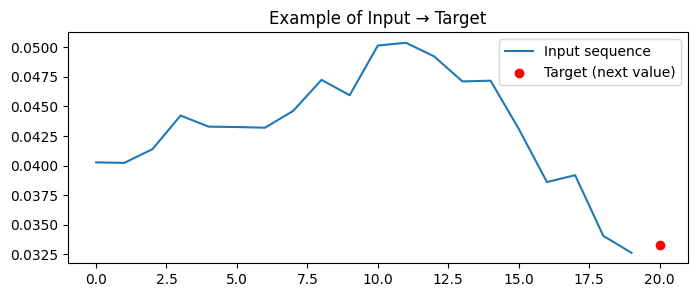

In [6]:
# Plot one input sequence and its target
plt.figure(figsize=(8,3))
plt.plot(range(window_size), X[0], label="Input sequence")
plt.scatter(window_size, y[0], color='red', label="Target (next value)")
plt.legend()
plt.title("Example of Input → Target")
plt.show()

## Train-Test Split (IMPORTANT: No shuffle)

In [7]:
# Use 80% for training
split = int(0.8 * len(X))

# Training data
X_train = X[:split]
y_train = y[:split]

# Testing data
X_test = X[split:]
y_test = y[split:]

# Print shapes
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1191, 20, 1)
Test shape: (298, 20, 1)


## HOLD OUT FUTURE DATA

In [8]:
# Hold last 50 points for future prediction
future_steps = 50

X_future = X_test[-future_steps:]   # inputs
y_future = y_test[-future_steps:]   # actual values

# Remove them from test set
X_test = X_test[:-future_steps]
y_test = y_test[:-future_steps]

print("Future set shape:", X_future.shape)

Future set shape: (50, 20, 1)


## Build CNN Model (TensorFlow)

In [9]:
# Define sequential CNN model
model = models.Sequential([

    # First convolution layer
    layers.Conv1D(
        filters=64,               # number of filters
        kernel_size=3,            # window size
        activation='relu',
        input_shape=(window_size, 1)
    ),

    # Downsampling
    layers.MaxPooling1D(pool_size=2),

    # Second convolution layer
    layers.Conv1D(32, 3, activation='relu'),

    # Downsampling again
    layers.MaxPooling1D(2),

    # Flatten into vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(50, activation='relu'),

    # Regularization
    layers.Dropout(0.2),

    # Output layer (next value prediction)
    layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile Model

In [10]:
# Compile model with optimizer and loss
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',       # mean squared error
    metrics=['mae']   # mean absolute error
)

## Train Model

In [11]:
# Train the CNN
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0643 - mae: 0.1712 - val_loss: 0.0068 - val_mae: 0.0736
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0069 - mae: 0.0566 - val_loss: 0.0028 - val_mae: 0.0464
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0057 - mae: 0.0507 - val_loss: 0.0042 - val_mae: 0.0573
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0053 - mae: 0.0487 - val_loss: 0.0032 - val_mae: 0.0498
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0044 - mae: 0.0452 - val_loss: 0.0027 - val_mae: 0.0456
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0043 - mae: 0.0445 - val_loss: 0.0020 - val_mae: 0.0395
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0044 - mae: 0.0453 - val_loss: 0.0107 - val_mae: 0.0946
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0042 - mae: 0.0453 - val_loss: 0.0029 - val_mae: 0.0474
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0042 - mae:

## Predict on Test Data

In [12]:
# Predict on test set
pred_test = model.predict(X_test)

# Convert back to original scale
pred_test = scaler.inverse_transform(pred_test)
y_test_actual = scaler.inverse_transform(y_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


## Predict FUTURE (held-out data)

In [13]:
# Predict future unseen data
pred_future = model.predict(X_future)

# Inverse scaling
pred_future = scaler.inverse_transform(pred_future)
y_future_actual = scaler.inverse_transform(y_future)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


## Final Visualization

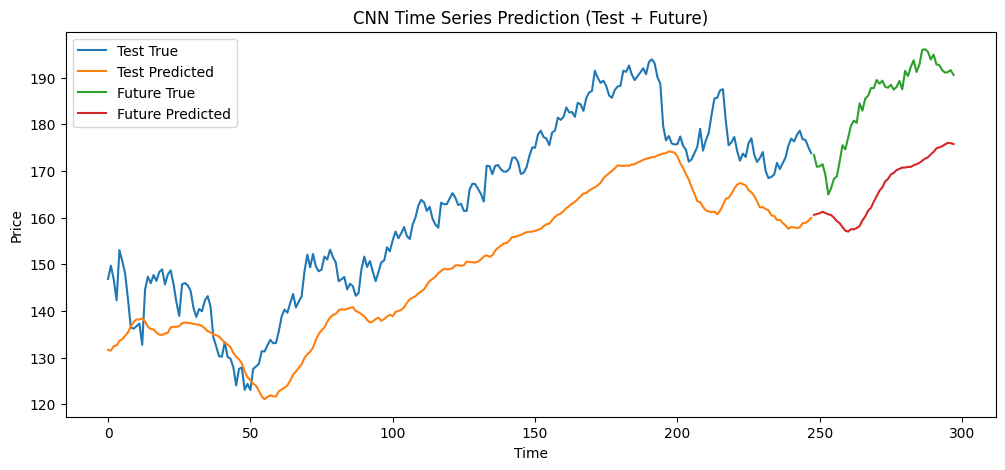

In [14]:
plt.figure(figsize=(12,5))

# Test predictions
plt.plot(y_test_actual, label="Test True")
plt.plot(pred_test, label="Test Predicted")

# Future predictions
plt.plot(
    range(len(y_test_actual), len(y_test_actual) + len(y_future_actual)),
    y_future_actual,
    label="Future True"
)

plt.plot(
    range(len(y_test_actual), len(y_test_actual) + len(pred_future)),
    pred_future,
    label="Future Predicted"
)

plt.legend()
plt.title("CNN Time Series Prediction (Test + Future)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()